# Lab: Logistic Regression
*In this lab, we will build a basic Logistic Regression model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1: Business Understanding Report (Summary)
> * **Business Context:** A botanical research institute has discovered that the *Iris-virginica* species possesses unique genetic properties that are valuable for developing new floral hybrids. To streamline their research and cultivation efforts, they need a fast and reliable method to distinguish *Iris-virginica* from other iris species like *setosa* and *versicolor*.
> * **Business Problem:** The current process of identifying *Iris-virginica* relies on manual inspection by expert botanist, which is slow, costly, and prone to human error. This bottleneck significantly delays the selection of flowers for research, hindering the institute's progress.
> * **Project Goal:** To build a **predictive classification model** that uses the physical measurements of an iris flower (sepal length, petal width, etc.) to automatically and accurately classify whether it is an *Iris-virginica* or not. The successful model will serve as a fast, cost-effective screening tool for the research team.

---

> ### 📝 2. Analytic Approach Report (Summary)
> * **Problem Type:** *Supervised Binary Classification*, as the goal is to predict a categorical outcome with two classes: "Is Virginica" (1) or "Not Virginica" (0).
> * **Model Selection:** We will use **Logistic Regression (via scikit-learn)** as our baseline model. This is an ideal starting point for classification problems as it is highly interpretable and provides a strong performance baseline.
> * **Evaluation Metrics:**  
>   * **Accuracy:** To get a quick, overall measure of the model's correctness.
>   * **Confusion Matrix:** To provide a detailed breakdown of correct and incorrect predictions for each class (True Positives, False Positives, etc.).
>   * **Precision, Recall, and F1-Score:** To deeply evaluate the model's performance, especially given the slight class imbalance. These metrics give us a nuanced understanding of how well the model identifies the positive class (*Iris-virginica*).
>   * **Data Preparation:** The modeling process will involve splitting the data into training and testing sets (80/20 split) and applying **feature scaling** (`StandardScaler`), as logistic regression benefits from having features on a comparable scale.
> 
> ⚠️ **Caution:** For this foundational lab, Logistic Regression is the only candidate model. In a real-world project, it would be standard practice to compare its performance against other algorithms (like SVMs, Decision Trees, etc.) to select the best possible solution.

---

> ### 📝 3. Data Requirements Report (Summary)
> * **Data Source:** The classic `iris.csv` dataset, which contains data on 150 iris flower samples.
> * **Features (Independent Variables):** `sepal_length`, `sepal_width`, `petal_length`, `petal_width` (all measurements are in centimeters).
> * **Target (Dependent Variable):** The original target is `species` (containing three uniqu classes). This will be transformed into a binary target column, `is_virginica`, where `1` represents *Iris-virginica* and `0` represents any other species.
> * **Granualarity & Privacy:** Each row represents an individual flower specimen. The dataset is a public, anonymized benchmark dataset and contains no sensitive or personally identifiable information (PII).

---

## Stage 4: Data Collection
We start with importing the necessary libraries and configuring them.

In [28]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")


### 4.1. Extract, Transform, Load (ETL)
Let's extract the data from the source system, which is Scikit-learn's built-in datasets, and perform the ETL process.

In [29]:
# Extract
raw = datasets.load_iris()
print(f"Data has been extracted from the source system as '{type(raw)}'")

Data has been extracted from the source system as '<class 'sklearn.utils._bunch.Bunch'>'


In [30]:
# Transform
df = pd.DataFrame(raw.data, columns=raw.feature_names)
df['class'] = raw.target
df['class_name'] = raw.target_names[raw.target]

In [31]:
# Load (as CSV)
df.to_csv("./data/iris_interim.csv", index=False)

### 4.2. Initial Data Ingestion and Verification
Let's perform a quick, high-level check to ensure the collected data is readable and appears correct.

In [32]:
df = pd.read_csv("./data/iris_interim.csv")
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class,class_name
30,4.8,3.1,1.6,0.2,0,setosa
144,6.7,3.3,5.7,2.5,2,virginica
53,5.5,2.3,4.0,1.3,1,versicolor
109,7.2,3.6,6.1,2.5,2,virginica
111,6.4,2.7,5.3,1.9,2,virginica


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int64  
 5   class_name         150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB



---

> ### 📝 4. Data Collection Report (Summary)
> * **Data Extraction:** The iris dataset was successfully extracted from Scikit-learn's built-in datasets using the `load_iris()` function.
> * **Data Transformation:** The raw data was transformed into a pandas DataFrame, with appropriate column names assigned. Two new columns were created: `class` (numerical target) and `class_name` (categorical target).
> * **Data Loading:** The transformed DataFrame was saved as a CSV file (`iris_interim.csv`) for further processing.
> * **Initial Verification:** A preliminary inspection of the DataFrame confirmed that the data was loaded correctly, with no missing values and suitable data types for each column.

---

## Stage 5: Data Understanding

### 5.1. Initial Data Shaping
Before diving into analysis, let's perform a first pass of cleaning and shaping.

In [34]:
# Load the data
iris_df = pd.read_csv("./data/iris_interim.csv")

# Rename columns for better readability
iris_df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class', 'class_name']

# Convert `class_name` and `class` columns to categories
iris_df['class_name'] = pd.Categorical(iris_df['class_name'])
iris_df['class'] = pd.Categorical(iris_df['class'])

# Create the binary target variable: `is_virginica`
iris_df['is_virginica'] = pd.Categorical(iris_df['class_name'] == 'virginica')

# Create lists for numerical and categorical column names for further use
numerical_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
categorical_cols = ['class', 'class_name', 'is_virginica']

# Display the changes
print("Sample of the data after initial shaping:")
display(iris_df.sample(5))
print("Value counts for our new binary target 'is_virginica':")
print(iris_df['is_virginica'].value_counts())

Sample of the data after initial shaping:


,sepal_length,sepal_width,petal_length,petal_width,class,class_name,is_virginica
64,5.6,2.9,3.6,1.3,1,versicolor,False
13,4.3,3.0,1.1,0.1,0,setosa,False
108,6.7,2.5,5.8,1.8,2,virginica,True
14,5.8,4.0,1.2,0.2,0,setosa,False
101,5.8,2.7,5.1,1.9,2,virginica,True


Value counts for our new binary target 'is_virginica':
is_virginica
False    100
True      50
Name: count, dtype: int64


Now let's check whether there are any outliers that are clearly the result of data entry errors or misdocumentation and can be confidently corrected or removed:

In [35]:
# Create a list to hold outlier indices
outlier_idx = []

# Iterate over each numerical columns
for col in numerical_cols:
    # Calculate Q1, Q3, and IQR
    q1 = iris_df[col].quantile(0.25)
    q3 = iris_df[col].quantile(0.75)
    iqr = q3 - q1

    # Define the outlier bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Find the indices of outliers for the current column
    outlier_id = iris_df[(iris_df[col] < lower_bound) | (iris_df[col] > upper_bound)].index
    
    # Add the indices to our list
    outlier_idx.extend(outlier_id)
    
# Get the unique outlier indices
unique_outlier_idx = sorted(list(set(outlier_idx)))

# Create the outliers_df using unique indices
outliers_df = iris_df.loc[unique_outlier_idx]

# Display the resulting DataFrame
print(f"Found {len(outliers_df)} rows containing at least one outlier value:")
outliers_df

Found 4 rows containing at least one outlier value:


,sepal_length,sepal_width,petal_length,petal_width,class,class_name,is_virginica
15,5.7,4.4,1.5,0.4,0,setosa,False
32,5.2,4.1,1.5,0.1,0,setosa,False
33,5.5,4.2,1.4,0.2,0,setosa,False
60,5.0,2.0,3.5,1.0,1,versicolor,False


### 5.2. Descriptive Statistics
Let's compute summary statistics to get a high-level quantitative overview of the dataset.

#### 5.2.1 Numerical Features

In [36]:
# Generate the descriptive statistics for the numerical variables
stats_df = iris_df[numerical_cols].describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9,0.141711
sepal_width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4,0.142564
petal_length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9,0.469744
petal_width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5,0.635551


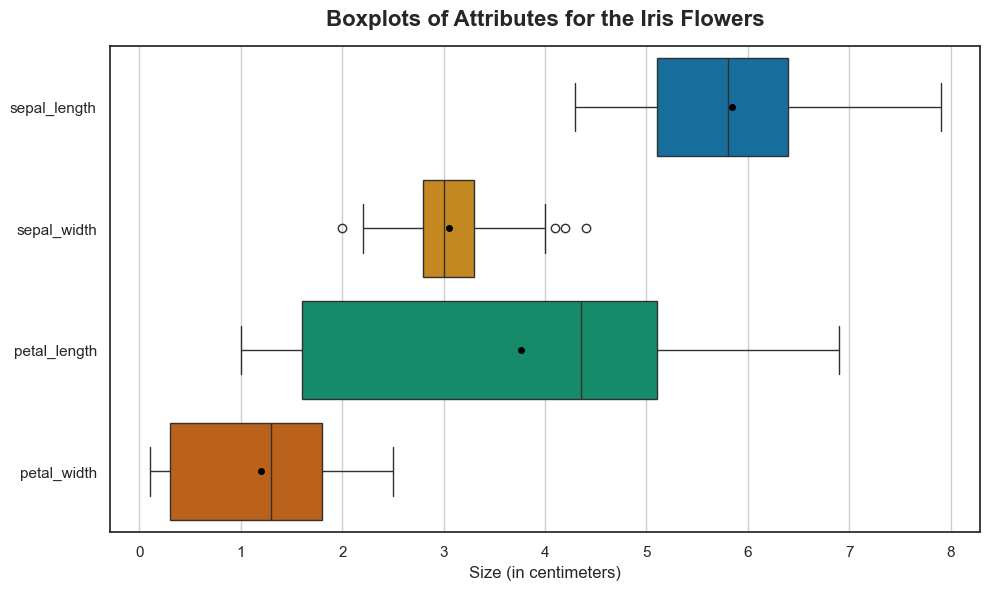

In [37]:
# Visualize the boxplots of numerical independent variables sharing the same units
plt.figure(figsize=(10, 6))
sns.boxplot(data=iris_df[numerical_cols], orient="h", showmeans=True, meanprops={
    "marker": "o",
    "markerfacecolor": "black",
    "markeredgecolor": "black",
    "markersize": "4"
})
plt.title("Boxplots of Attributes for the Iris Flowers", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Size (in centimeters)")
plt.grid(axis="x")
plt.show()

#### 5.2.2. Categorical Features
Now let's take a look at the descriptive statistics for the categorical features.

In [38]:
iris_categorical = iris_df[categorical_cols]
iris_categorical.describe().T

,count,unique,top,freq
class,150,3,0,50
class_name,150,3,setosa,50
is_virginica,150,2,False,100


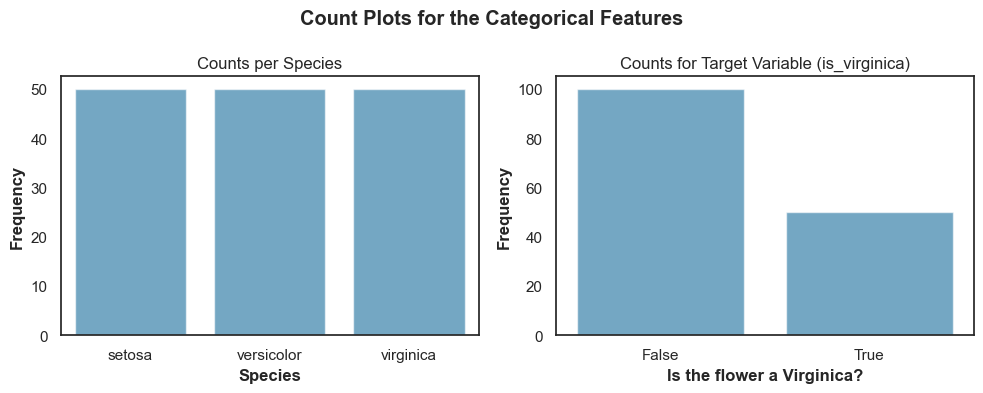

In [39]:
# Visualize the categorical columns
fig, axs = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle("Count Plots for the Categorical Features", fontweight="bold")

sns.countplot(iris_categorical, x="class_name", ax=axs[0], alpha=0.6)
axs[0].set_title("Counts per Species")
axs[0].set_xlabel("Species", fontweight="bold")
axs[0].set_ylabel("Frequency", fontweight="bold")

sns.countplot(iris_categorical, x="is_virginica", ax=axs[1], alpha=0.6)
axs[1].set_title("Counts for Target Variable (is_virginica)")
axs[1].set_xlabel("Is the flower a Virginica?", fontweight="bold")
axs[1].set_ylabel("Frequency", fontweight="bold")

plt.tight_layout()
plt.show()

### 5.3. Univariate Analysis
Now it's time to analyze individual variables to understand their own distributions and characteristics.

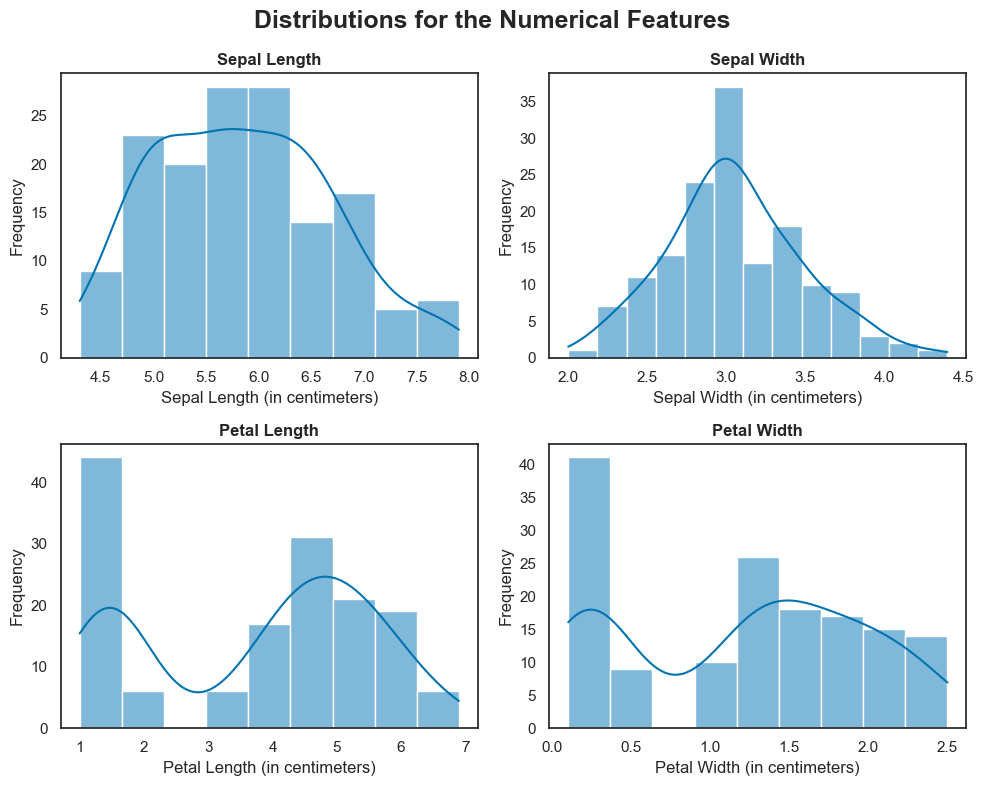

In [40]:
fig, axs = plt.subplots(2,2, figsize=(10, 8))
fig.suptitle("Distributions for the Numerical Features", fontweight="bold", fontsize=18)

sns.histplot(iris_df, x="sepal_length", ax=axs[0, 0], kde=True)
axs[0, 0].set_title("Sepal Length", fontweight="bold")
axs[0, 0].set_xlabel("Sepal Length (in centimeters)")
axs[0, 0].set_ylabel("Frequency")

sns.histplot(iris_df, x="sepal_width", ax=axs[0, 1], kde=True)
axs[0, 1].set_title("Sepal Width", fontweight="bold")
axs[0, 1].set_xlabel("Sepal Width (in centimeters)")
axs[0, 1].set_ylabel("Frequency")

sns.histplot(iris_df, x="petal_length", ax=axs[1, 0], kde=True)
axs[1, 0].set_title("Petal Length", fontweight="bold")
axs[1, 0].set_xlabel("Petal Length (in centimeters)")
axs[1, 0].set_ylabel("Frequency")

sns.histplot(iris_df, x="petal_width", ax=axs[1, 1], kde=True)
axs[1, 1].set_title("Petal Width", fontweight="bold")
axs[1, 1].set_xlabel("Petal Width (in centimeters)")
axs[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 5.4. Bivariate Analysis
Now let's analyze pairs of variables to investigate relationships and correlations. We'll start with the pair plot, and then use a correlation matrix to further investigate any multicollinearities.

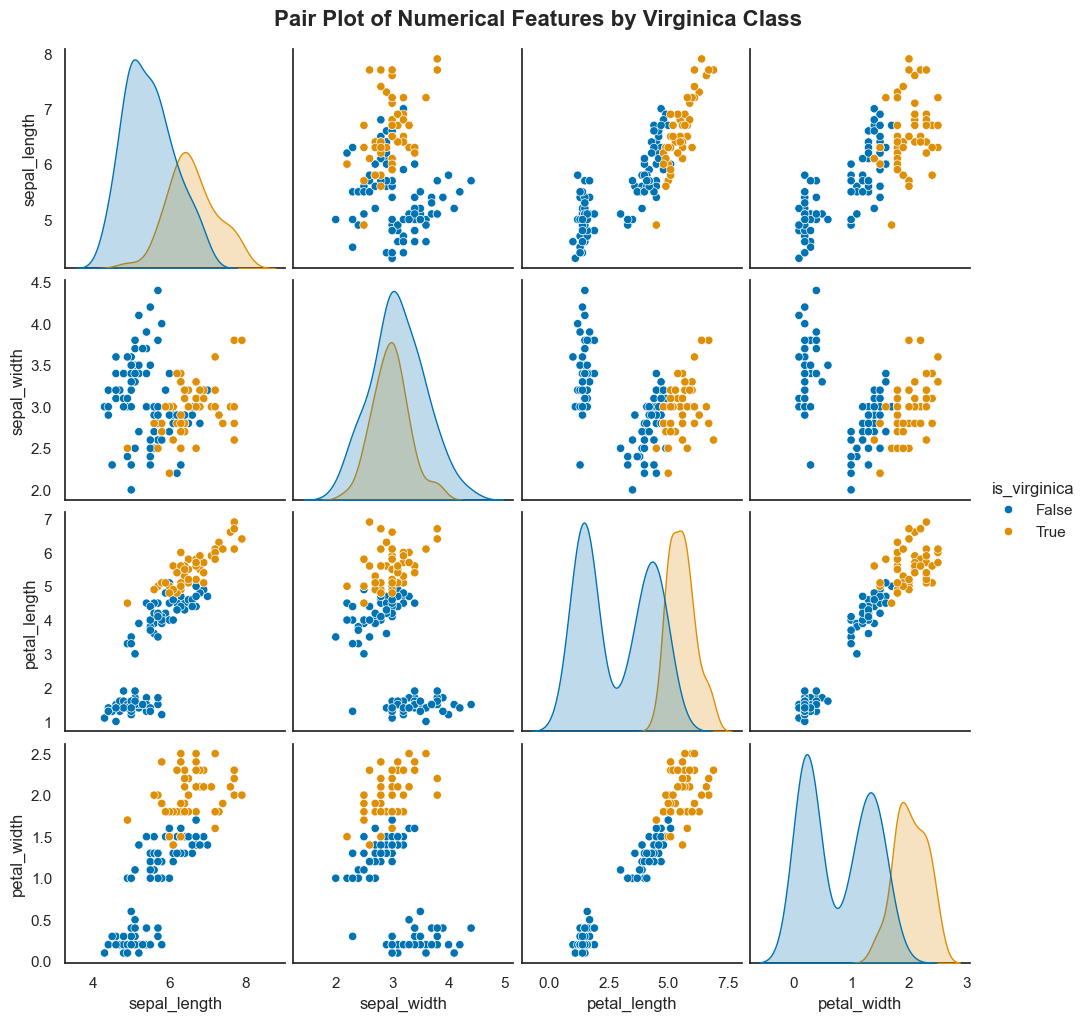

In [41]:
# Create a list of columns to use for the bivariate analysis
bivariate_cols = numerical_cols.copy()
bivariate_cols.append('is_virginica')

# Display the Pair Plot
pairplot = sns.pairplot(iris_df[bivariate_cols], hue="is_virginica")
pairplot.figure.suptitle("Pair Plot of Numerical Features by Virginica Class", fontsize=16, fontweight="bold", y=1.02)
plt.show()

In [42]:
# Display the correlation matrix
iris_df[numerical_cols].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000



---

> ### 📝 5. Data Understanding Report (Summary)
> * **Initial Data Shaping:** 
>   * Renamed columns for better readability, converted `class` and `class_name` columns to categorical data types, and created a binary target column `is_virginica` for the classification task. 
>   * All four outlier values were plausible flower measurements, therefore no deletion was needed. Plus, three of them belong to the setosa class. Iris setosa is known to have wider sepals relative to its other dimensions. The fourth outlier is a versicolor with a particularly narrow sepal width (2.0 cm).
>  
> * **Descriptive Statistics:** 
>   * The numerical features are on different absolute scales, which confirms the necessity of scaling during the Data Preparation stage.
>   * They have different relative variability (CVs range from ≈0.14 to ≈0.64) and can be grouped by relative spread:
>       * Low relative variability: `sepal_length` (cv ≈ 0.14), `sepal_width` (cv ≈ 0.14).
>       * Higher relative variability: `petal_length` (cv ≈ 0.47), `petal_width` (cv ≈ 0.64).
>   * Sepal measures appear fairly symmetric and compact. `sepal_width` shows 4 points outside the usual IQR-based range that should be inspected before deciding whether to correct or remove them.
>   * Petal measures have a wider spread, indicating greater variability and potential discriminative power; `petal_width` has the highest relative spread. Although the means are smaller than the medians, the right whiskers are longer — this combination suggests asymmetry that could be due to multimodality or a small number of high values, and it needs visual inspection (histogram/KDE) to resolve.
>   * The `class_name` column has 3 unique values (setosa, versicolor, and virginica), with 50 observations for each, making the original dataset perfectly balanced.
>   * The binary target variable `is_virginica` has 100 False values and 50 True values. This 2:1 ratio makes the dataset imbalanced, which is an important consideration for model training and evaluation.
> 
> * **Univariate Analysis:**
>   * The `sepal_length` and `sepal_width` features both display unimodal, roughly symmetric (bell-shaped) distributions, similar to a normal distribution.
>   * The plots for `petal_length` and `petal_width` clearly show bimodal distributions (two distinct peaks). This is a strong indicator that these features effectively separate different underlying groups within the data, making them likely to be very powerful predictors for our classification model.
> * **Bivariate Analysis:**
>   * The pair plots visually confirm that `petal_length` and `petal_width` are powerful predictors. The `is_virginica=True` class (orange) is clearly separated from the False class (blue) along the axes for these two features.
>   * However, the correlation matrix reveals a correlation of 0.96 between `petal_length` and `petal_width`. This indicates extreme multicollinearity. To prevent issues with model interpretability and coefficient stability, we should consider either removing one of these features or combining them (e.g., creating petal_area).
>   * The matrix also shows strong correlations between `sepal_length` and the petal features (0.87 and 0.82), suggesting some shared information.
>   * The sepal features show significant overlap between the two classes in the pair plots, confirming they are much weaker predictors on their own.  
>
> ⚠️ **Caution:** For this lab, we will proceed by keeping all features to see their effect on the baseline model. A common strategy to manage multicollinearity is to use regularization (e.g., Ridge or Lasso), but those techniques are outside the scope of this introductory exercise.


---